# Analyze the results of the T cell parameter estimations

Find the optimal parameter combinations for each mouse.

It requires that the parameter estimation has been completed and there exists a file with those results (from running runner_t.py). Edit the location of those files below.

## Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.formula import api as smf
import os
import seaborn as sns
from scipy.stats import ttest_ind
from estimator import Estimator
from src import pyxfunc

## User-defined parameters

In [2]:
growth_data_file = "data/growth_data_df.csv"

result_path = "results_path/"

figure_save_path = "figures/" # Set to None to not save figures
best_value_save_path = "bests/" # Set to None to not save

## Set up

In [3]:
groups_b6 = ["Grp. A1 B6 (100% C1)", "Grp. A2 B6 (80% C1; 20% C11)", "Grp. A3 B6 (50% C1; 50% C11)", "Grp. A4 B6 (20% C1; 80% C11)", "Grp. A5 B6 (100% C11)"]
growth_df = pd.read_csv(growth_data_file)
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]
growth_df.loc[growth_df["group"]=="1C", "group"] = "Grp. A1 B6 (100% C1)"
growth_df.loc[growth_df["group"]=="2C", "group"] = "Grp. A2 B6 (80% C1; 20% C11)"
growth_df.loc[growth_df["group"]=="3C", "group"] = "Grp. A3 B6 (50% C1; 50% C11)"
growth_df.loc[growth_df["group"]=="4C", "group"] = "Grp. A4 B6 (20% C1; 80% C11)"
growth_df.loc[growth_df["group"]=="5C", "group"] = "Grp. A5 B6 (100% C11)"

## Read in and prep data

In [4]:
df = []
for fname in [f for f in os.listdir(result_path)]:
    temp = pd.read_csv(result_path+fname)
    temp = temp[~(temp["id"].isin(exclude))]
    df += [temp]
df = pd.concat(df)
df = df.drop_duplicates()
df = df[df["error"] != np.inf]
df

,group,id,g1,g11,m,k,c,a,f,b,l,error,winner
0,Grp. A1 B6 (100% C1),424,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.01,0.01,1.348847e+08,0
1,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.01,0.01,5.381148e+12,0
2,Grp. A1 B6 (100% C1),427,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.01,0.01,4.322136e+10,0
3,Grp. A1 B6 (100% C1),424,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.02,0.01,1.355618e+08,0
4,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.02,0.01,5.413486e+12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
686998,5C,701,0.166,0.141,-0.090,0.075,1.00,2.0,2.0,0.10,0.01,8.026724e+05,1
686999,5C,703,0.166,0.141,-0.090,0.075,1.00,2.0,2.0,0.10,0.01,1.597273e+06,1
687000,5C,704,0.166,0.141,-0.090,0.075,1.00,2.0,2.0,0.10,0.01,6.428619e+05,1
687001,5C,715,0.166,0.141,-0.090,0.075,1.00,2.0,2.0,0.10,0.01,2.715328e+06,1


In [5]:
df.loc[df["group"]=="1C", "group"] = "Grp. A1 B6 (100% C1)"
df.loc[df["group"]=="2C", "group"] = "Grp. A2 B6 (80% C1; 20% C11)"
df.loc[df["group"]=="3C", "group"] = "Grp. A3 B6 (50% C1; 50% C11)"
df.loc[df["group"]=="4C", "group"] = "Grp. A4 B6 (20% C1; 80% C11)"
df.loc[df["group"]=="5C", "group"] = "Grp. A5 B6 (100% C11)"
df

,group,id,g1,g11,m,k,c,a,f,b,l,error,winner
0,Grp. A1 B6 (100% C1),424,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.01,0.01,1.348847e+08,0
1,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.01,0.01,5.381148e+12,0
2,Grp. A1 B6 (100% C1),427,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.01,0.01,4.322136e+10,0
3,Grp. A1 B6 (100% C1),424,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.02,0.01,1.355618e+08,0
4,Grp. A1 B6 (100% C1),425,0.166,0.142,-0.025,-0.010,0.02,0.1,0.1,0.02,0.01,5.413486e+12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
686998,Grp. A5 B6 (100% C11),701,0.166,0.141,-0.090,0.075,1.00,2.0,2.0,0.10,0.01,8.026724e+05,1
686999,Grp. A5 B6 (100% C11),703,0.166,0.141,-0.090,0.075,1.00,2.0,2.0,0.10,0.01,1.597273e+06,1
687000,Grp. A5 B6 (100% C11),704,0.166,0.141,-0.090,0.075,1.00,2.0,2.0,0.10,0.01,6.428619e+05,1
687001,Grp. A5 B6 (100% C11),715,0.166,0.141,-0.090,0.075,1.00,2.0,2.0,0.10,0.01,2.715328e+06,1


In [6]:
df.loc[df["group"]=="Grp. A1 B6 (100% C1)", "g11"] = 0
df.loc[df["group"]=="Grp. A1 B6 (100% C1)","m"] = 0
df.loc[df["group"]=="Grp. A1 B6 (100% C1)","k"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","c"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","a"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","f"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","b"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","m"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","k"] = 0
df.loc[df["group"]=="Grp. A5 B6 (100% C11)","g1"] = 0
if "h" in df.columns: # For the supplementary model with an h parameter
    df.loc[df["group"]=="Grp. A1 B6 (100% C1)","h"] = 0 

df = df.drop_duplicates()
df = df.reset_index(drop=True)

## Find top $n$ tuples with the lowest error

In [7]:
n = 100
bests = []
for mid in df["id"].unique():
    m_df = df[df["id"] == mid]
    m_df = m_df.sort_values("error").reset_index()
    cutoff = m_df.loc[min(n-1, len(m_df)-1),"error"]
    m_df = m_df[m_df["error"] <= cutoff]
    bests += [m_df]
bests = pd.concat(bests)
bests = bests.drop_duplicates()
bests["logaf"] = np.log(bests["a"]/bests["f"])
bests["logbc"] = np.log(bests["b"]/bests["c"])
bests["logkm"] = np.log(bests["k"]/np.abs(bests["m"]))
bests = bests.sort_values(["group", "id"])
bests

,index,group,id,g1,g11,m,k,c,a,f,b,l,error,winner,logaf,logbc,logkm
0,8870911,Grp. A1 B6 (100% C1),424,0.166,0.000,0.0,0.0,0.04,1.9,1.7,0.03,0.01,2.818525e+02,0,0.111226,-0.287682,NaN
1,30245206,Grp. A1 B6 (100% C1),424,0.166,0.000,0.0,0.0,0.16,0.5,0.3,0.03,0.01,3.587186e+02,0,0.510826,-1.673976,NaN
2,17523749,Grp. A1 B6 (100% C1),424,0.171,0.000,0.0,0.0,0.08,1.5,1.2,0.05,0.01,4.531875e+02,0,0.223144,-0.470004,NaN
3,35130451,Grp. A1 B6 (100% C1),424,0.171,0.000,0.0,0.0,0.18,0.4,0.3,0.02,0.01,4.682853e+02,0,0.287682,-2.197225,NaN
4,21743748,Grp. A1 B6 (100% C1),424,0.171,0.000,0.0,0.0,0.12,1.2,1.2,0.03,0.01,4.951667e+02,0,0.000000,-1.386294,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,215623,Grp. A5 B6 (100% C11),715,0.000,0.141,0.0,0.0,0.00,0.0,0.0,0.00,0.01,2.715328e+06,1,NaN,NaN,NaN
2,215618,Grp. A5 B6 (100% C11),715,0.000,0.142,0.0,0.0,0.00,0.0,0.0,0.00,0.01,2.970656e+06,1,NaN,NaN,NaN
0,215629,Grp. A5 B6 (100% C11),721,0.000,0.127,0.0,0.0,0.00,0.0,0.0,0.00,0.01,3.081733e+04,1,NaN,NaN,NaN
1,215624,Grp. A5 B6 (100% C11),721,0.000,0.141,0.0,0.0,0.00,0.0,0.0,0.00,0.01,2.688022e+05,1,NaN,NaN,NaN


In [8]:
if best_value_save_path:
    bests.to_csv(best_value_save_path+"t_{}.csv".format(n), index=False)

## Linear relationships between the parameters

In [16]:
bests_no_a5 = bests[bests["group"]!="Grp. A5 B6 (100% C11)"]
bests_no_a5 = bests_no_a5[bests_no_a5["id"]!=602]
bests_no_a5.loc[bests_no_a5["group"]=="Grp. A1 B6 (100% C1)", "group"] = "A1"
bests_no_a5.loc[bests_no_a5["group"]=="Grp. A2 B6 (80% C1; 20% C11)", "group"] = "A2"
bests_no_a5.loc[bests_no_a5["group"]=="Grp. A3 B6 (50% C1; 50% C11)", "group"] = "A3"
bests_no_a5.loc[bests_no_a5["group"]=="Grp. A4 B6 (20% C1; 80% C11)", "group"] = "A4"
bests_no_a5 = bests_no_a5.reset_index()

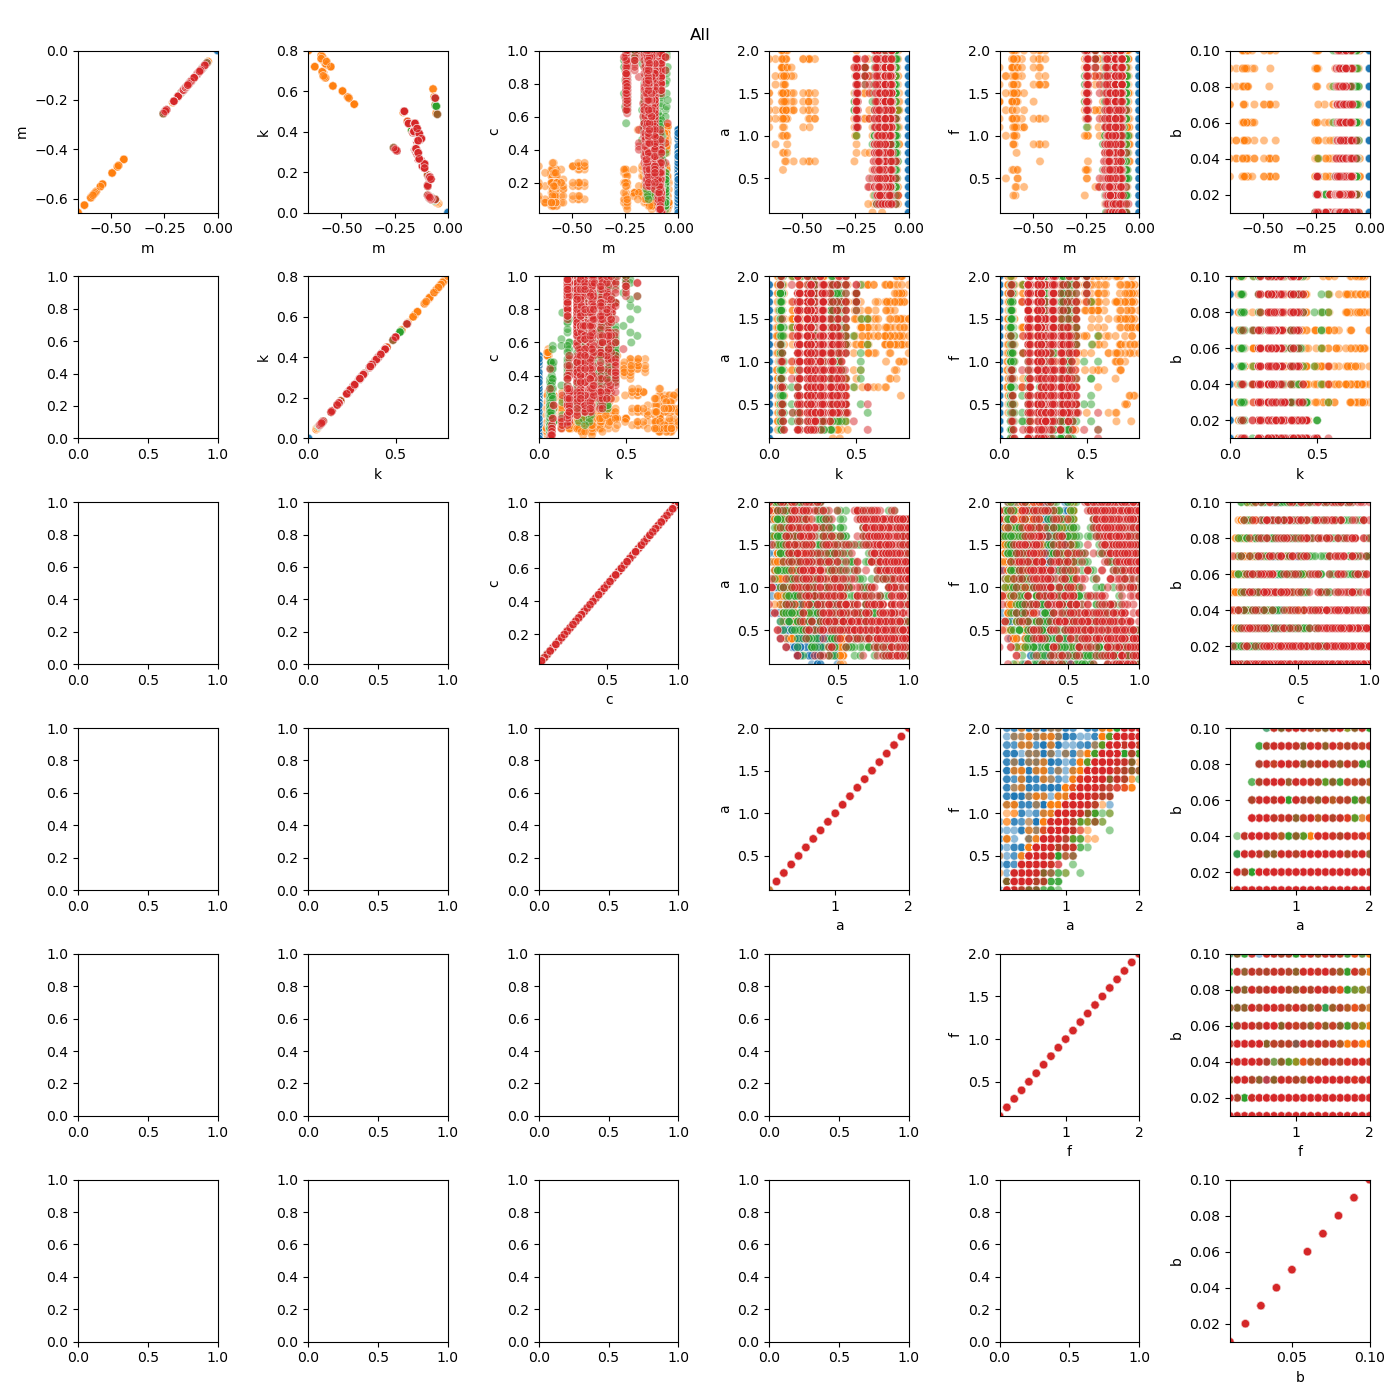

In [17]:
params = ["m", "k", "c", "a", "f", "b"]
group = 3
fig, axes = plt.subplots(nrows=len(params), ncols=len(params), figsize=(14,14))
for i in range(len(params)):
    for j in range(i, len(params)):
        sns.scatterplot(bests_no_a5, x=params[i], y=params[j], hue="group", alpha=0.5, legend=False, ax=axes[i][j])
        axes[i][j].set(xlabel= params[i], ylabel=params[j], xlim=(bests_no_a5[params[i]].min(), bests_no_a5[params[i]].max()), ylim=(bests_no_a5[params[j]].min(), bests_no_a5[params[j]].max()))
fig.suptitle("All")
plt.tight_layout()
plt.show()

In [18]:
# R^2 values for a linear relationship between c and a
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("c~a", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

A1 424 0.298
A1 425 0.106
A1 427 0.332
A1 600 0.491
A1 601 0.005
A1 609 0.708
A2 431 0.144
A2 432 0.022
A2 433 0.013
A2 435 0.488
A2 627 0.043
A2 633 0.129
A2 637 0.028
A2 648 0.04
A3 436 0.343
A3 439 0.195
A3 440 0.579
A3 441 0.386
A3 653 0.012
A3 655 0.045
A3 660 0.153
A3 668 0.228
A4 444 0.4
A4 445 0.623
A4 446 0.398
A4 447 0.115
A4 683 0.594
A4 686 0.006
A4 687 0.511
A4 689 0.007
A4 697 0.191


In [19]:
# R^2 values for a linear relationship between c and f
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("c~f", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

A1 424 0.038
A1 425 0.114
A1 427 0.076
A1 600 0.005
A1 601 0.0
A1 609 0.043
A2 431 0.023
A2 432 0.002
A2 433 0.0
A2 435 0.332
A2 627 0.01
A2 633 0.027
A2 637 0.017
A2 648 0.014
A3 436 0.253
A3 439 0.138
A3 440 0.509
A3 441 0.246
A3 653 0.0
A3 655 0.081
A3 660 0.19
A3 668 0.247
A4 444 0.347
A4 445 0.642
A4 446 0.368
A4 447 0.075
A4 683 0.51
A4 686 0.015
A4 687 0.487
A4 689 0.018
A4 697 0.08


In [20]:
# R^2 values for a linear relationship between c and b
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("c~b", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

A1 424 0.007
A1 425 0.314
A1 427 0.225
A1 600 0.23
A1 601 0.008
A1 609 0.027
A2 431 0.099
A2 432 0.247
A2 433 0.006
A2 435 0.014
A2 627 0.191
A2 633 0.34
A2 637 0.196
A2 648 0.027
A3 436 0.019
A3 439 0.106
A3 440 0.006
A3 441 0.093
A3 653 0.005
A3 655 0.031
A3 660 0.07
A3 668 0.13
A4 444 0.001
A4 445 0.061
A4 446 0.018
A4 447 0.008
A4 683 0.073
A4 686 0.008
A4 687 0.0
A4 689 0.018
A4 697 0.014


In [21]:
# R^2 values for a linear relationship between a and f
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("a~f", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

A1 424 0.774
A1 425 0.211
A1 427 0.217
A1 600 0.281
A1 601 0.034
A1 609 0.084
A2 431 0.928
A2 432 0.906
A2 433 0.106
A2 435 0.959
A2 627 0.812
A2 633 0.646
A2 637 0.919
A2 648 0.944
A3 436 0.894
A3 439 0.988
A3 440 0.951
A3 441 0.828
A3 653 0.972
A3 655 0.985
A3 660 0.936
A3 668 0.944
A4 444 0.94
A4 445 0.965
A4 446 0.971
A4 447 0.993
A4 683 0.984
A4 686 0.981
A4 687 0.953
A4 689 0.995
A4 697 0.914


In [22]:
# R^2 values for a linear relationship between a and b
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("a~b", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

A1 424 0.232
A1 425 0.303
A1 427 0.164
A1 600 0.014
A1 601 0.968
A1 609 0.158
A2 431 0.508
A2 432 0.496
A2 433 0.929
A2 435 0.304
A2 627 0.141
A2 633 0.306
A2 637 0.373
A2 648 0.798
A3 436 0.194
A3 439 0.03
A3 440 0.275
A3 441 0.093
A3 653 0.0
A3 655 0.004
A3 660 0.151
A3 668 0.073
A4 444 0.37
A4 445 0.003
A4 446 0.286
A4 447 0.01
A4 683 0.018
A4 686 0.05
A4 687 0.209
A4 689 0.01
A4 697 0.049


In [23]:
# R^2 values for a linear relationship between f and b
for mid in bests_no_a5["id"].unique():
    lr = smf.ols("f~b", bests_no_a5[bests_no_a5["id"]==mid]).fit()
    print(bests_no_a5[bests_no_a5["id"]==mid].iloc[0]["group"], mid, round(lr.rsquared, 3))

A1 424 0.14
A1 425 0.012
A1 427 0.0
A1 600 0.01
A1 601 0.0
A1 609 0.054
A2 431 0.654
A2 432 0.494
A2 433 0.012
A2 435 0.383
A2 627 0.005
A2 633 0.013
A2 637 0.211
A2 648 0.593
A3 436 0.065
A3 439 0.007
A3 440 0.193
A3 441 0.031
A3 653 0.008
A3 655 0.021
A3 660 0.035
A3 668 0.008
A4 444 0.243
A4 445 0.011
A4 446 0.222
A4 447 0.003
A4 683 0.001
A4 686 0.111
A4 687 0.103
A4 689 0.004
A4 697 0.0
